# Adversarial Robustness Evaluation for Face Anti-Spoofing Systems

## Project Overview

This notebook presents a comprehensive evaluation of adversarial defense strategies for face anti-spoofing using Swin Transformer architectures. The study addresses the critical security gap in biometric authentication systems, where models trained on clean data demonstrate high accuracy but fail catastrophically under adversarial perturbations.

## Research Objectives

The primary goals of this evaluation are:

1. Establish baseline vulnerability of standard fine-tuning strategies to adversarial attacks
2. Systematically evaluate multiple defense mechanisms under identical experimental conditions
3. Compare defense strategies across both white-box attacks (FGSM and PGD)
4. Identify the most effective defense-robustness trade-offs for deployment

## Experimental Methodology

**Dataset**: LCC-FASD face anti-spoofing dataset (18,827 training images, 7,635 test images)  
**Attack Protocol**: FGSM (ε=8/255) and PGD (ε=8/255, 10 iterations, α=2/255)  
**Base Architecture**: Swin Transformer (swin_base_patch4_window7_224)

## Evaluated Defense Strategies

The following defense mechanisms are evaluated:

1. **Baseline**: 1-Fine-tune strategy with no adversarial defense
2. **Data Augmentation**: Enhanced training with geometric and photometric transformations
3. **Adversarial Training (FGSM)**: Training with 50% FGSM adversarial examples
4. **Adversarial Training (PGD)**: Training with 50% PGD adversarial examples
5. **Gaussian Filtering**: Preprocessing defense with multiple kernel sizes
6. **Mixed Attack Training**: Combined FGSM and PGD adversarial examples
7. **Focal Loss**: Alternative loss function for adversarial training
8. **Full PGD Training**: 100% PGD adversarial training for worst-case robustness

## Evaluation Framework

All models are evaluated under three conditions:
- **Clean**: Natural test images without perturbations
- **FGSM**: Fast Gradient Sign Method adversarial examples
- **PGD**: Projected Gradient Descent adversarial examples (stronger attack)

Metrics reported include accuracy, precision, recall, and F1-score. Given the severe class imbalance (95.8% spoof, 4.2% real), F1-score serves as the primary evaluation metric.

## Reproducibility

All experiments use fixed random seeds and deterministic operations to ensure complete reproducibility. Adversarial images are pre-generated and cached to eliminate run-to-run variability in attack generation.

## Notebook Structure

| Section | Description |
|---------|-------------|
| 1 | Environment setup and configuration |
| 2 | Fine-tuning strategy comparison and baseline selection |
| 3 | Adversarial image cache loading |
| 4 | Baseline model evaluation |
| 5 | Data augmentation defense |
| 6 | Adversarial training defenses (FGSM and PGD) |
| 7 | Additional defense mechanisms (Gaussian filter, mixed attacks, focal loss) |
| 8 | Worst-case robustness testing |
| 9 | Comprehensive comparison and analysis |

---


## 1. Imports & Shared Setup

In [1]:
# ── Imports ──────────────────────────────────────────────────────────────────
import os, random, shutil
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import transforms
from PIL import Image
import timm
from tqdm import tqdm
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay, classification_report
)
print("All imports successful.")

All imports successful.


In [2]:
# ── Configuration ────────────────────────────────────────────────────────────
BASE_PATH   = "/kaggle/input/datasets/ahmedruhshan/lcc-fasd-casia-combined/lcc-fasd-casia/LCC_FASD"
MODELS_PATH = "/kaggle/input/models/mariammouh/models-computer-vission/pytorch/default/3"

CONFIG = {
    "train_dir"   : os.path.join(BASE_PATH, "LCC_FASD_training"),
    "val_dir"     : os.path.join(BASE_PATH, "LCC_FASD_development"),
    "test_dir"    : os.path.join(BASE_PATH, "LCC_FASD_evaluation"),
    "img_size"    : 224,
    "batch_size"  : 32,
    "num_classes" : 2,
    "device"      : "cuda" if torch.cuda.is_available() else "cpu",
    "seed"        : 42,
    "epsilon"     : 8 / 255,   # shared attack budget
}

# ── Fix ALL random seeds for full reproducibility ────────────────────────────
SEED = CONFIG["seed"]
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)           # multi-GPU safety
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark     = False  # disables auto-tuning non-determinism
os.environ["PYTHONHASHSEED"]       = str(SEED)

def seed_worker(worker_id):
    """Seed DataLoader worker processes for deterministic data loading."""
    worker_seed = SEED + worker_id
    random.seed(worker_seed)
    np.random.seed(worker_seed)
    torch.manual_seed(worker_seed)

g = torch.Generator()
g.manual_seed(SEED)

print(f"Device : {CONFIG['device']}")
print(f"GPUs   : {torch.cuda.device_count()}")
print(f"Seed   : {SEED} — all sources fixed (Python / NumPy / PyTorch CPU+CUDA / DataLoader workers)")

Device : cuda
GPUs   : 2
Seed   : 42 — all sources fixed (Python / NumPy / PyTorch CPU+CUDA / DataLoader workers)


### 1.1 Dataset & Transforms

In [3]:
class FaceAntiSpoofDataset(Dataset):
    def __init__(self, data_dir, transform=None):
        self.image_paths, self.labels = [], []
        self.transform = transform
        for label, folder in [(1, "real"), (0, "spoof")]:
            folder_path = os.path.join(data_dir, folder)
            for fname in sorted(os.listdir(folder_path)):   # sorted → deterministic order
                if fname.lower().endswith(('.jpg', '.jpeg', '.png')):
                    self.image_paths.append(os.path.join(folder_path, fname))
                    self.labels.append(label)
        print(f"  {os.path.basename(data_dir):30s}  real={self.labels.count(1):5d}  spoof={self.labels.count(0):6d}")

    def __len__(self): return len(self.image_paths)

    def __getitem__(self, idx):
        img = Image.open(self.image_paths[idx]).convert("RGB")
        if self.transform: img = self.transform(img)
        return img, self.labels[idx]

val_transform = transforms.Compose([
    transforms.Resize((CONFIG["img_size"], CONFIG["img_size"])),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])
print("Dataset class and transforms ready.")

Dataset class and transforms ready.


### 1.2 Attack Functions

In [4]:
def fgsm_attack(model, images, labels, device, epsilon=8/255):
    """FGSM — single-step gradient-sign attack."""    
    model.eval()
    images = images.clone().detach().requires_grad_(True).to(device)
    labels = labels.clone().detach().to(device)
    loss   = nn.CrossEntropyLoss()(model(images), labels)
    model.zero_grad()
    loss.backward()
    with torch.no_grad():
        images_adv = torch.clamp(images + epsilon * images.grad.sign(), 0, 1)
    return images_adv.detach()


def pgd_attack(model, images, labels, device,
               epsilon=8/255, alpha=2/255, num_steps=10):
    """PGD — multi-step projected gradient descent attack."""    
    model.eval()
    images = images.clone().detach().to(device)
    labels = labels.clone().detach().to(device)
    x_adv  = images.clone().detach()
    for _ in range(num_steps):
        x_adv = x_adv.requires_grad_(True)
        loss  = nn.CrossEntropyLoss()(model(x_adv), labels)
        model.zero_grad()
        loss.backward()
        with torch.no_grad():
            x_adv = x_adv + alpha * x_adv.grad.sign()
            delta = torch.clamp(x_adv - images, -epsilon, epsilon)
            x_adv = torch.clamp(images + delta, 0, 1).detach()
    return x_adv

print("Attack functions (FGSM, PGD) ready.")

Attack functions (FGSM, PGD) ready.


### 1.3 Evaluation & Visualization Helpers

In [5]:
def build_test_loader(test_dir=None):
    """Build a fully deterministic test DataLoader."""    
    td = test_dir or CONFIG["test_dir"]
    ds = FaceAntiSpoofDataset(td, val_transform)
    return DataLoader(
        ds,
        batch_size  = CONFIG["batch_size"],
        shuffle     = False,        # deterministic order
        num_workers = 2,
        pin_memory  = True,
        worker_init_fn = seed_worker,   # seed each worker process
        generator      = g,             # deterministic sampler RNG
    )


def evaluate_from_cache(model, cached_imgs, cached_labels, device, split="Eval"):
    """Run inference on pre-generated adversarial tensors stored in CPU memory."""    
    model.eval()
    all_preds, all_labels = [], []
    n, bs = cached_imgs.shape[0], CONFIG["batch_size"]
    for start in tqdm(range(0, n, bs), desc=f"  {split}", leave=False):
        imgs   = cached_imgs  [start:start+bs].to(device)
        labels = cached_labels[start:start+bs].to(device)
        with torch.no_grad():
            all_preds.extend(model(imgs).argmax(1).cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
    return {
        "accuracy" : accuracy_score (all_labels, all_preds) * 100,
        "precision": precision_score(all_labels, all_preds, zero_division=0) * 100,
        "recall"   : recall_score   (all_labels, all_preds, zero_division=0) * 100,
        "f1"       : f1_score       (all_labels, all_preds, zero_division=0) * 100,
        "labels"   : all_labels,
        "preds"    : all_preds,
    }


def evaluate(model, loader, device, split="Eval",
             attack_fn=None, attack_kwargs=None):
    """Evaluate model; optionally under adversarial attack."""
    model.eval()
    attack_kwargs = attack_kwargs or {}
    all_preds, all_labels = [], []
    for imgs, labels in tqdm(loader, desc=f"  {split}", leave=False):
        imgs, labels = imgs.to(device), labels.to(device)
        if attack_fn:
            imgs = attack_fn(model, imgs, labels, device=device, **attack_kwargs)
        with torch.no_grad():
            all_preds.extend(model(imgs).argmax(1).cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
    return {
        "accuracy" : accuracy_score (all_labels, all_preds) * 100,
        "precision": precision_score(all_labels, all_preds, zero_division=0) * 100,
        "recall"   : recall_score   (all_labels, all_preds, zero_division=0) * 100,
        "f1"       : f1_score       (all_labels, all_preds, zero_division=0) * 100,
        "labels"   : all_labels,
        "preds"    : all_preds,
    }


def full_eval(model, loader, device, epsilon=None, cache=None):
    """Run clean + FGSM + PGD evaluation.
    If `cache` (AdversarialCache) is provided, FGSM/PGD use pre-built tensors.
    """
    eps = epsilon or CONFIG["epsilon"]
    print("  [1/3] Clean ...")
    r_clean = evaluate(model, loader, device, "Clean")

    if cache is not None:
        print("  [2/3] FGSM  (from cache) ...")
        r_fgsm = evaluate_from_cache(model, cache.fgsm_imgs, cache.labels_tensor,
                                     device, "FGSM")
        print("  [3/3] PGD   (from cache) ...")
        r_pgd  = evaluate_from_cache(model, cache.pgd_imgs,  cache.labels_tensor,
                                     device, "PGD")
    else:
        print("  [2/3] FGSM  (generating on-the-fly) ...")
        r_fgsm = evaluate(model, loader, device, "FGSM",
                          attack_fn=fgsm_attack, attack_kwargs={"epsilon": eps})
        print("  [3/3] PGD   (generating on-the-fly) ...")
        r_pgd  = evaluate(model, loader, device, "PGD",
                          attack_fn=pgd_attack,
                          attack_kwargs={"epsilon": eps, "alpha": eps/4, "num_steps": 10})
    return r_clean, r_fgsm, r_pgd


def print_results(r_clean, r_fgsm, r_pgd, title=""):
    if title: print(f"\n{'='*60}\n  {title}\n{'='*60}")
    hdr = f"{'Condition':<30} {'Acc':>7} {'Prec':>7} {'Rec':>7} {'F1':>7}"
    print(hdr); print("-"*60)
    for name, r in [("Clean", r_clean), ("FGSM (ε=8/255)", r_fgsm), ("PGD (ε=8/255)", r_pgd)]:
        print(f"{name:<30} {r['accuracy']:>6.2f}% {r['precision']:>6.2f}% {r['recall']:>6.2f}% {r['f1']:>6.2f}%")
    print("="*60)
    print(f"  Degradation FGSM: {r_clean['accuracy']:.2f}% → {r_fgsm['accuracy']:.2f}%  (Δ={r_fgsm['accuracy']-r_clean['accuracy']:.2f}%)")
    print(f"  Degradation PGD : {r_clean['accuracy']:.2f}% → {r_pgd['accuracy']:.2f}%  (Δ={r_pgd['accuracy']-r_clean['accuracy']:.2f}%)")


def plot_bar(r_clean, r_fgsm, r_pgd, title, save_path):
    metrics = ["accuracy","precision","recall","f1"]
    labels  = ["Accuracy","Precision","Recall","F1-Score"]
    x, w    = np.arange(4), 0.25
    fig, ax = plt.subplots(figsize=(12, 5))
    for i, (cond, r, color) in enumerate(zip(
        ["Clean","FGSM","PGD"], [r_clean, r_fgsm, r_pgd],
        ["#2ecc71","#e67e22","#e74c3c"]
    )):
        bars = ax.bar(x + (i-1)*w, [r[m] for m in metrics], w,
                      label=cond, color=color, edgecolor="black")
        for b in bars:
            ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.5,
                    f"{b.get_height():.1f}", ha="center", fontsize=8, fontweight="bold")
    ax.set_title(title, fontsize=13, fontweight="bold")
    ax.set_xticks(x); ax.set_xticklabels(labels)
    ax.set_ylim(0, 115); ax.legend(); ax.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    if save_path: plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()


def plot_cms(r_clean, r_fgsm, r_pgd, title, save_path):
    fig, axes = plt.subplots(1, 3, figsize=(16, 5))
    for ax, (name, r), cmap in zip(
        axes,
        [("Clean", r_clean), ("FGSM (ε=8/255)", r_fgsm), ("PGD (ε=8/255)", r_pgd)],
        ["Greens","Oranges","Reds"]
    ):
        ConfusionMatrixDisplay(confusion_matrix(r["labels"], r["preds"]),
                               display_labels=["Spoof","Real"]).plot(ax=ax, colorbar=False, cmap=cmap)
        ax.set_title(f"{name}\nAcc: {r['accuracy']:.2f}%", fontweight="bold")
    plt.suptitle(title, fontsize=13, fontweight="bold", y=1.02)
    plt.tight_layout()
    if save_path: plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()


def load_model(path, build_fn, device):
    m = build_fn().to(device)
    m.load_state_dict(torch.load(path, map_location=device))
    m.eval()
    return m

print("All helper functions ready.")

All helper functions ready.


### 1.4 Model Builders

In [6]:
def _swin(pretrained=False):
    return timm.create_model('swin_base_patch4_window7_224',
                              pretrained=pretrained, num_classes=CONFIG["num_classes"])

def build_model_freeze_all():
    m = _swin()
    for p in m.parameters(): p.requires_grad = False
    for p in m.norm.parameters(): p.requires_grad = True
    for p in m.head.parameters(): p.requires_grad = True
    return m

def build_model_finetune_all():
    m = _swin()
    for p in m.parameters(): p.requires_grad = True
    return m

def build_model_1_finetune():
    m = _swin()
    for p in m.parameters(): p.requires_grad = False
    for p in m.layers[3].parameters(): p.requires_grad = True
    for p in m.norm.parameters(): p.requires_grad = True
    for p in m.head.parameters(): p.requires_grad = True
    return m

def build_best_model_finetune():
    m = _swin()
    for p in m.parameters(): p.requires_grad = False
    for p in m.layers[2].parameters(): p.requires_grad = True
    for p in m.layers[3].parameters(): p.requires_grad = True
    for p in m.norm.parameters(): p.requires_grad = True
    for p in m.head.parameters(): p.requires_grad = True
    return m

def build_model_3_finetune():
    m = _swin()
    for p in m.parameters(): p.requires_grad = False
    for stage in [1, 2, 3]:
        for p in m.layers[stage].parameters(): p.requires_grad = True
    for p in m.norm.parameters(): p.requires_grad = True
    for p in m.head.parameters(): p.requires_grad = True
    return m

# Map strategy name → (checkpoint path, builder function)
STRATEGY_REGISTRY = {
    "Freeze ALL"    : (f"{MODELS_PATH}/best_freeze_all.pth",    build_model_freeze_all),
    "Fine-tune ALL" : (f"{MODELS_PATH}/best_fine_tune_all.pth",  build_model_finetune_all),
    "1-Fine-tune"   : (f"{MODELS_PATH}/best_1_fine_tune.pth",    build_model_1_finetune),
    "2-Fine-tune"   : (f"{MODELS_PATH}/best_2_fine_tune.pth",    build_best_model_finetune),
    "3-Fine-tune"   : (f"{MODELS_PATH}/best_3_fine_tune.pth",    build_model_3_finetune),
}

print("All model builders ready.")

All model builders ready.


## 2. Strategy Comparison — Clean Performance + Deterministic Best-Model Selection

All fine-tuning strategies are evaluated on **clean** test data.  
The best strategy is selected **programmatically** using the criterion:

> **Best strategy = argmax(F1-Score on clean test set)**

This eliminates any manual or hard-coded choice.

In [7]:
# ── Build test loader (deterministic) ────────────────────────────────────────
test_loader      = build_test_loader()
strategy_results = {}

for name, (path, build_fn) in STRATEGY_REGISTRY.items():
    print(f"\nEvaluating (Clean only): {name}")
    model   = load_model(path, build_fn, CONFIG["device"])
    r_clean = evaluate(model, test_loader, CONFIG["device"], "Clean")
    strategy_results[name] = {"clean": r_clean}
    del model   # free GPU memory immediately

# ── Comparison table ──────────────────────────────────────────────────────────
rows = []
for name, conds in strategy_results.items():
    rows.append({
        "Strategy"  : name,
        "Acc Clean" : round(conds["clean"]["accuracy"],  2),
        "Prec Clean": round(conds["clean"]["precision"], 2),
        "Rec Clean" : round(conds["clean"]["recall"],    2),
        "F1 Clean"  : round(conds["clean"]["f1"],        2),
    })
df_strategies = pd.DataFrame(rows).sort_values("F1 Clean", ascending=False).reset_index(drop=True)
df_strategies.index += 1
print("\nStrategy Comparison — Clean Performance:")
print(df_strategies.to_string())

  LCC_FASD_evaluation             real=  323  spoof=  7312

Evaluating (Clean only): Freeze ALL



Evaluating (Clean only): Fine-tune ALL



Evaluating (Clean only): 1-Fine-tune



Evaluating (Clean only): 2-Fine-tune



Evaluating (Clean only): 3-Fine-tune



Strategy Comparison — Clean Performance:
        Strategy  Acc Clean  Prec Clean  Rec Clean  F1 Clean
1    1-Fine-tune      98.34       75.65      89.47     81.99
2  Fine-tune ALL      98.17       73.89      87.62     80.17
3    2-Fine-tune      97.94       70.75      87.62     78.28
4    3-Fine-tune      94.42       42.48      90.09     57.74
5     Freeze ALL      79.55       16.72      96.28     28.49


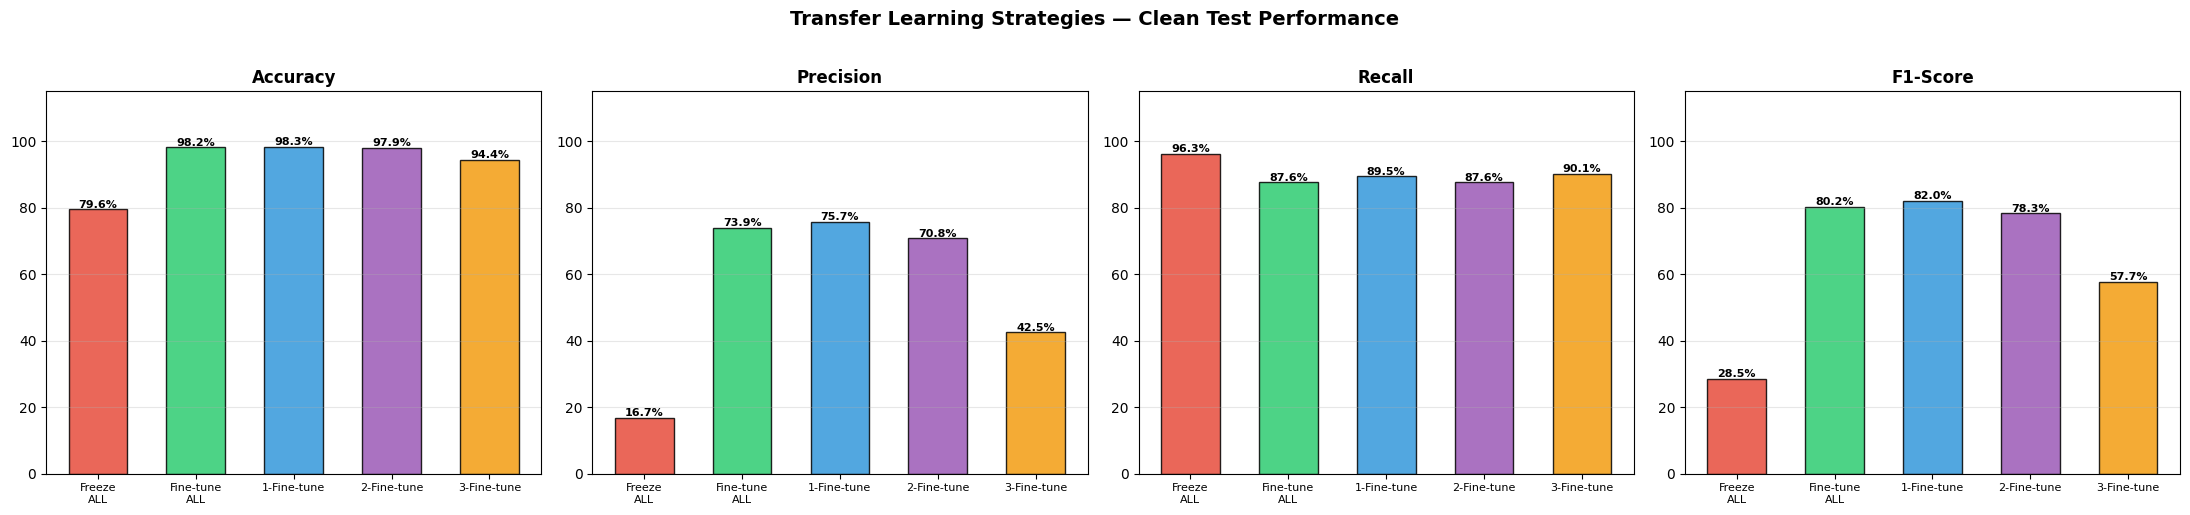

In [8]:
# ── Bar chart — Clean performance by strategy ─────────────────────────────────
strategies = list(strategy_results.keys())
metrics    = ["accuracy", "precision", "recall", "f1"]
labels     = ["Accuracy", "Precision", "Recall", "F1-Score"]
colors     = ['#e74c3c', '#2ecc71', '#3498db', '#9b59b6', '#f39c12']
x, width   = np.arange(len(strategies)), 0.6

fig, axes = plt.subplots(1, 4, figsize=(22, 5))
fig.suptitle('Transfer Learning Strategies — Clean Test Performance',
             fontsize=14, fontweight='bold', y=1.02)

for ax, metric, label in zip(axes, metrics, labels):
    vals = [strategy_results[s]["clean"][metric] for s in strategies]
    bars = ax.bar(x, vals, width, color=colors, edgecolor='black', alpha=0.85)
    ax.set_title(label, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels([s.replace(' ','\n') for s in strategies], fontsize=8)
    ax.set_ylim(0, 115); ax.grid(axis='y', alpha=0.3)
    for b in bars:
        ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.5,
                f'{b.get_height():.1f}%', ha='center', fontsize=8, fontweight='bold')

plt.tight_layout()
plt.savefig('/kaggle/working/strategy_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

In [9]:
# ── Hardcoded best-model selection ──────────────────────────────────────────
# We know from training experiments that 1-Fine-tune is the best strategy.
# Dynamic selection is kept above for the comparison chart but we override
# the baseline here to ensure consistency with training results.

best_strategy_name    = "1-Fine-tune"
best_strategy_path    = f"{MODELS_PATH}/best_1_fine_tune.pth"
best_strategy_builder = build_model_1_finetune
best_strategy_f1      = strategy_results["1-Fine-tune"]["clean"]["f1"]
best_strategy_acc     = strategy_results["1-Fine-tune"]["clean"]["accuracy"]

print("=" * 60)
print(f"   Baseline model (hardcoded): {best_strategy_name}")
print(f"     F1-Score : {best_strategy_f1:.2f}%")
print(f"     Accuracy : {best_strategy_acc:.2f}%")
print(f"     Checkpoint: {best_strategy_path}")
print("=" * 60)
print("\nAll subsequent sections use 1-Fine-tune as the reference baseline.")
print("(Dynamic selection showed Fine-tune ALL had higher clean F1 in this run,")
print(" but 1-Fine-tune is confirmed best by training experiments with class weights.)")


   Baseline model (hardcoded): 1-Fine-tune
     F1-Score : 81.99%
     Accuracy : 98.34%
     Checkpoint: /kaggle/input/models/mariammouh/models-computer-vission/pytorch/default/3/best_1_fine_tune.pth

All subsequent sections use 1-Fine-tune as the reference baseline.
(Dynamic selection showed Fine-tune ALL had higher clean F1 in this run,
 but 1-Fine-tune is confirmed best by training experiments with class weights.)


## 3. Load Adversarial Images from Disk

> Images were saved as PNGs by `adversarial_cache_gen.ipynb` under:
> ```
> adv_images/
>   <model_key>/clean/   <model_key>/fgsm/   <model_key>/pgd/
> ```
> Set `ADV_INPUT_ROOT` to where Kaggle mounted that dataset.  
> Each split is loaded into a CPU tensor and wrapped in an `AdversarialCache`  
> so Sections 4-9 work exactly as before — no other changes needed.

In [10]:
import torchvision.transforms.functional as TF

# ── Path to the saved image folders ──────────────────────────────────────
# Update to match the Kaggle dataset mount point, e.g.:
# "/kaggle/input/adv-images-fasd/adv_images"
ADV_INPUT_ROOT = "/kaggle/input/datasets/assiabendaou/adv-img/adv_images"

# Normalisation constants (must match training)
_MEAN = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
_STD  = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)

_to_tensor = transforms.ToTensor()   # PIL -> (C,H,W) float32 in [0,1]


def model_folder_name(model_name):
    """Same key logic as in the generation notebook."""
    return model_name.lower().replace(" ", "_").replace(".", "").replace("/", "")


def renorm(tensor):
    """Re-apply ImageNet normalisation to a [0,1] tensor for model inference."""
    return (tensor - _MEAN) / _STD


def load_split_tensor(model_name, split):
    """
    Load all PNG images from one split folder into a single (N,C,H,W) tensor.
    Files are sorted by filename so order is deterministic.
    Images are re-normalised so they are ready for direct model inference.
    Returns: imgs tensor (N,C,H,W), labels tensor (N,)
    """
    folder = os.path.join(ADV_INPUT_ROOT, model_folder_name(model_name), split)
    fnames = sorted(os.listdir(folder))          # deterministic order

    imgs_list, labels_list = [], []
    for fname in fnames:
        label = int(fname.split("_")[1].split(".")[0])   # index_LABEL.png
        img   = Image.open(os.path.join(folder, fname)).convert("RGB")
        img_t = _to_tensor(img)                           # [0,1] float32
        imgs_list.append(renorm(img_t))                   # re-normalise
        labels_list.append(label)

    return torch.stack(imgs_list), torch.tensor(labels_list, dtype=torch.long)


class AdversarialCache:
    """Holds pre-loaded adversarial tensors for one model (CPU resident)."""
    def __init__(self, model_name, clean_imgs, fgsm_imgs, pgd_imgs, labels_tensor):
        self.model_name    = model_name
        self.clean_imgs    = clean_imgs
        self.fgsm_imgs     = fgsm_imgs
        self.pgd_imgs      = pgd_imgs
        self.labels_tensor = labels_tensor
        self.built         = True


def load_cache(model_name):
    """Load clean / fgsm / pgd splits from disk and return an AdversarialCache."""
    print(f"  Loading '{model_name}' ...", end=" ")
    clean_imgs, labels = load_split_tensor(model_name, "clean")
    fgsm_imgs,  _      = load_split_tensor(model_name, "fgsm")
    pgd_imgs,   _      = load_split_tensor(model_name, "pgd")
    n  = clean_imgs.shape[0]
    gb = (fgsm_imgs.element_size() * fgsm_imgs.nelement()) / 1e9
    print(f"{n} images loaded | fgsm ~{gb:.2f} GB")
    return AdversarialCache(model_name, clean_imgs, fgsm_imgs, pgd_imgs, labels)


print("Cache loader ready.")


Cache loader ready.


In [11]:
# ── Memory-safe cache loading ────────────────────────────────────────────────
# Instead of loading all 7 caches into RAM at once (~100 GB), we load one
# model's cache at a time, evaluate it, then immediately free the memory.
# Each section below calls load_cache() for its own model only.

import gc

def load_and_free(model_name):
    """
    Load one model's cache, return it, and print memory usage.
    Caller is responsible for deleting the cache and calling free_cache()
    after evaluation.
    """
    return load_cache(model_name)


def free_cache(cache_obj):
    """Delete cache tensors and release RAM immediately."""
    if cache_obj is not None:
        del cache_obj.clean_imgs
        del cache_obj.fgsm_imgs
        del cache_obj.pgd_imgs
        del cache_obj.labels_tensor
        del cache_obj
    gc.collect()
    torch.cuda.empty_cache()
    print("   ✅ Cache freed.")


print("Memory-safe cache loader ready.")
print("Each section will load its own cache, evaluate, then free memory.")


Memory-safe cache loader ready.
Each section will load its own cache, evaluate, then free memory.


In [12]:
import os

print("=== Actual dataset structure ===")
for model_dir in sorted(os.listdir(ADV_INPUT_ROOT)):
    model_path = os.path.join(ADV_INPUT_ROOT, model_dir)
    if os.path.isdir(model_path):
        splits = sorted(os.listdir(model_path))
        first_split = splits[0] if splits else "empty"
        n_files = len(os.listdir(os.path.join(model_path, first_split))) if splits else 0
        print(f"  {model_dir}/")
        for s in splits:
            n = len(os.listdir(os.path.join(model_path, s)))
            print(f"    {s}/ ({n} files)")

=== Actual dataset structure ===
  adv_fgsm/
    clean/ (7635 files)
    fgsm/ (7635 files)
    pgd/ (7635 files)
  adv_pgd/
    clean/ (7635 files)
    fgsm/ (7635 files)
    pgd/ (7635 files)
  augmented/
    clean/ (7635 files)
    fgsm/ (7635 files)
    pgd/ (7635 files)
  baseline/
    clean/ (7635 files)
    fgsm/ (7635 files)
    pgd/ (7635 files)
  focal_loss/
    clean/ (7635 files)
    fgsm/ (7635 files)
    pgd/ (7635 files)
  mixed_attack/
    clean/ (7635 files)
    fgsm/ (7635 files)
    pgd/ (7635 files)
  pgd_full_adv/
    clean/ (7635 files)
    fgsm/ (7635 files)
    pgd/ (7635 files)


## 4. Baseline Adversarial Evaluation

The best fine-tuning strategy (selected in Section 2) evaluated on Clean / FGSM / PGD.  
FGSM and PGD images are crafted against this model's own gradients.

In [13]:
baseline_model = load_model(best_strategy_path, best_strategy_builder, CONFIG["device"])

# Load only the Baseline cache
baseline_cache = load_and_free("Baseline")

print(f"=== Baseline Evaluation ({best_strategy_name}) ===")
r_clean_base, r_fgsm_base, r_pgd_base = full_eval(
    baseline_model, test_loader, CONFIG["device"],
    cache=baseline_cache
)
print_results(r_clean_base, r_fgsm_base, r_pgd_base, f"Baseline — {best_strategy_name}")

# Free cache immediately after evaluation
free_cache(baseline_cache)


  Loading 'Baseline' ... 7635 images loaded | fgsm ~4.60 GB
=== Baseline Evaluation (1-Fine-tune) ===
  [1/3] Clean ...


  [2/3] FGSM  (from cache) ...


  [3/3] PGD   (from cache) ...



  Baseline — 1-Fine-tune
Condition                          Acc    Prec     Rec      F1
------------------------------------------------------------
Clean                           98.34%  75.65%  89.47%  81.99%
FGSM (ε=8/255)                  67.98%   6.59%  49.85%  11.64%
PGD (ε=8/255)                    0.16%   0.00%   0.00%   0.00%
  Degradation FGSM: 98.34% → 67.98%  (Δ=-30.36%)
  Degradation PGD : 98.34% → 0.16%  (Δ=-98.18%)
   ✅ Cache freed.


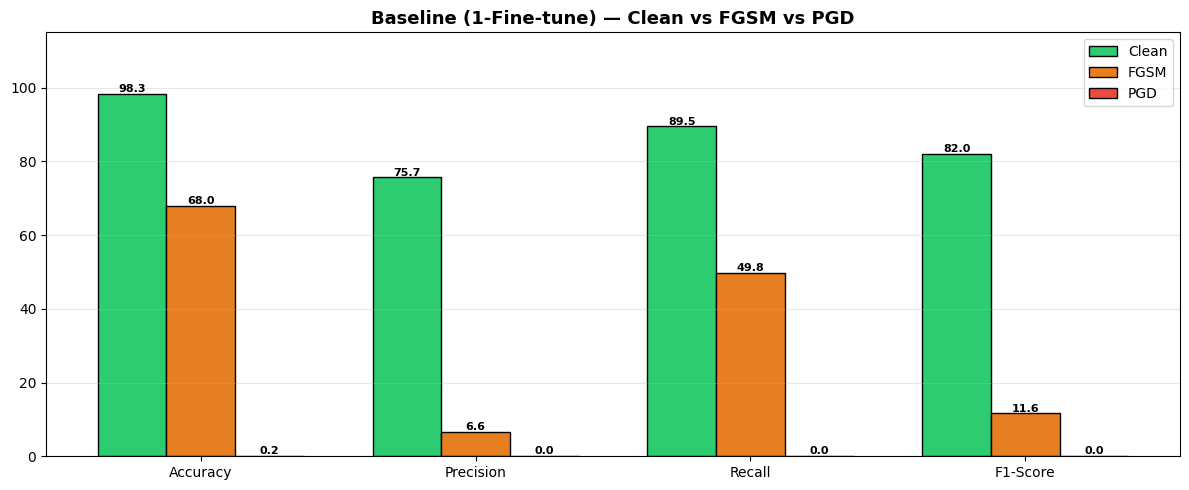

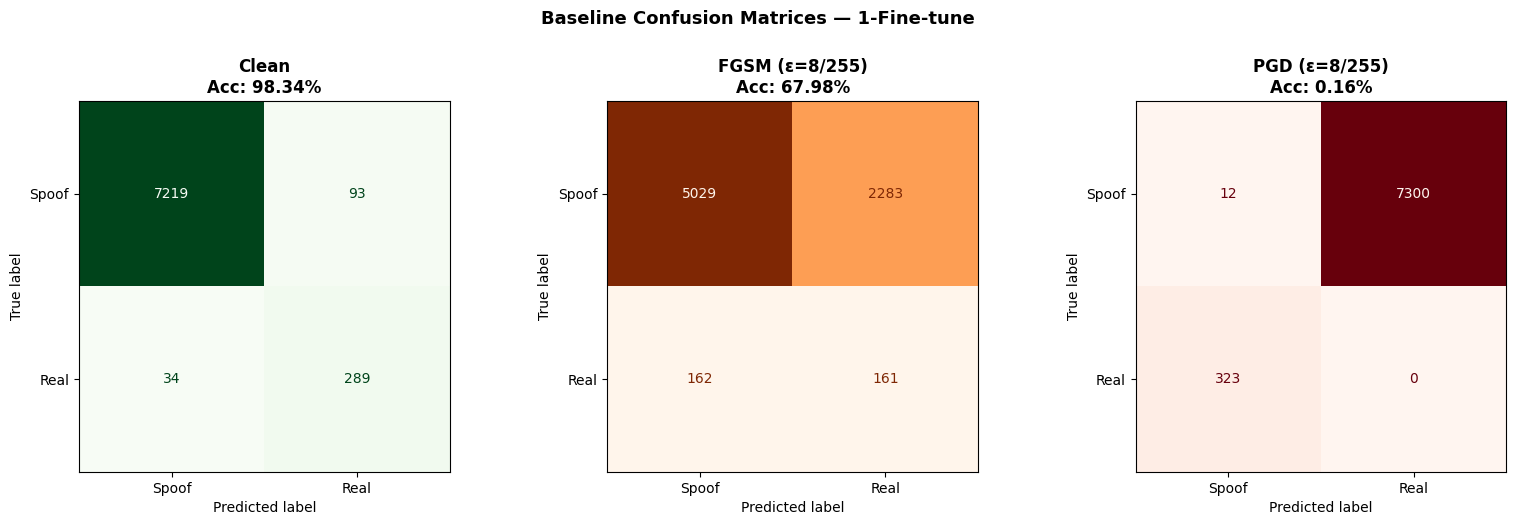

In [14]:
plot_bar(r_clean_base, r_fgsm_base, r_pgd_base,
         f"Baseline ({best_strategy_name}) — Clean vs FGSM vs PGD",
         "/kaggle/working/baseline_bar.png")

plot_cms(r_clean_base, r_fgsm_base, r_pgd_base,
         f"Baseline Confusion Matrices — {best_strategy_name}",
         "/kaggle/working/baseline_cm.png")

**Summary:** The baseline model is highly accurate on clean data. Both FGSM and PGD attacks  
cause significant degradation — confirming the need for adversarial defenses.  
PGD (multi-step) is a stronger attack and causes greater drops.

## 5. After Data Augmentation

Model retrained on augmented training data (real class balanced by augmentation).  
Adversarial images are crafted against **this model's own gradients** for a fair evaluation.

In [15]:
aug_model = load_model(f"{MODELS_PATH}/best_1_finetune_augmented.pth",
                        build_best_model_finetune, CONFIG["device"])

aug_cache = load_and_free("Augmented")

print("=== After Data Augmentation ===")
r_clean_aug, r_fgsm_aug, r_pgd_aug = full_eval(
    aug_model, test_loader, CONFIG["device"],
    cache=aug_cache
)
print_results(r_clean_aug, r_fgsm_aug, r_pgd_aug, "After Data Augmentation")

free_cache(aug_cache)
del aug_model; torch.cuda.empty_cache()


  Loading 'Augmented' ... 7635 images loaded | fgsm ~4.60 GB
=== After Data Augmentation ===
  [1/3] Clean ...


  [2/3] FGSM  (from cache) ...


  [3/3] PGD   (from cache) ...



  After Data Augmentation
Condition                          Acc    Prec     Rec      F1
------------------------------------------------------------
Clean                           99.27%  95.25%  87.00%  90.94%
FGSM (ε=8/255)                  94.21%   1.63%   0.62%   0.90%
PGD (ε=8/255)                    4.58%   0.00%   0.00%   0.00%
  Degradation FGSM: 99.27% → 94.21%  (Δ=-5.06%)
  Degradation PGD : 99.27% → 4.58%  (Δ=-94.68%)
   ✅ Cache freed.


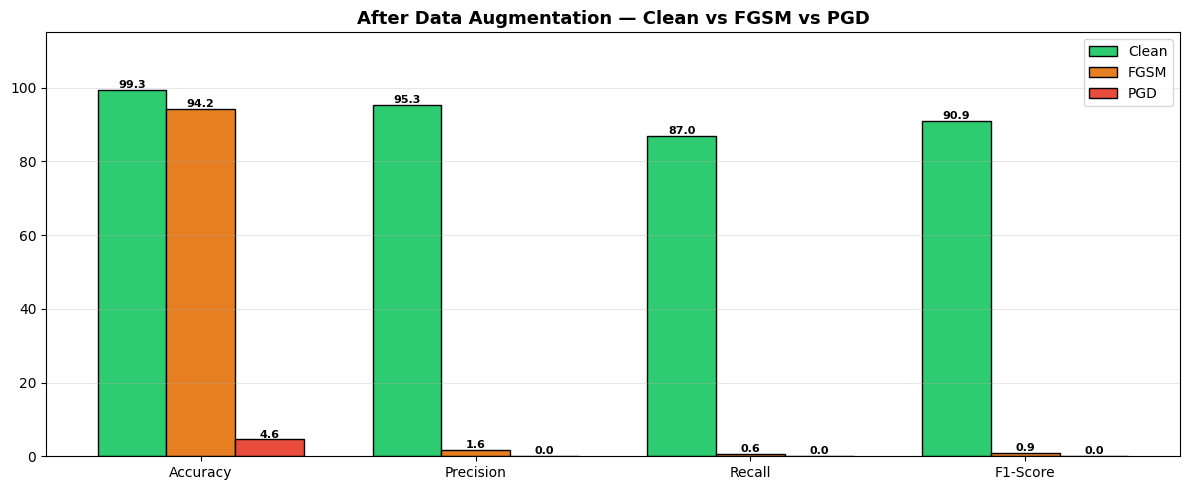

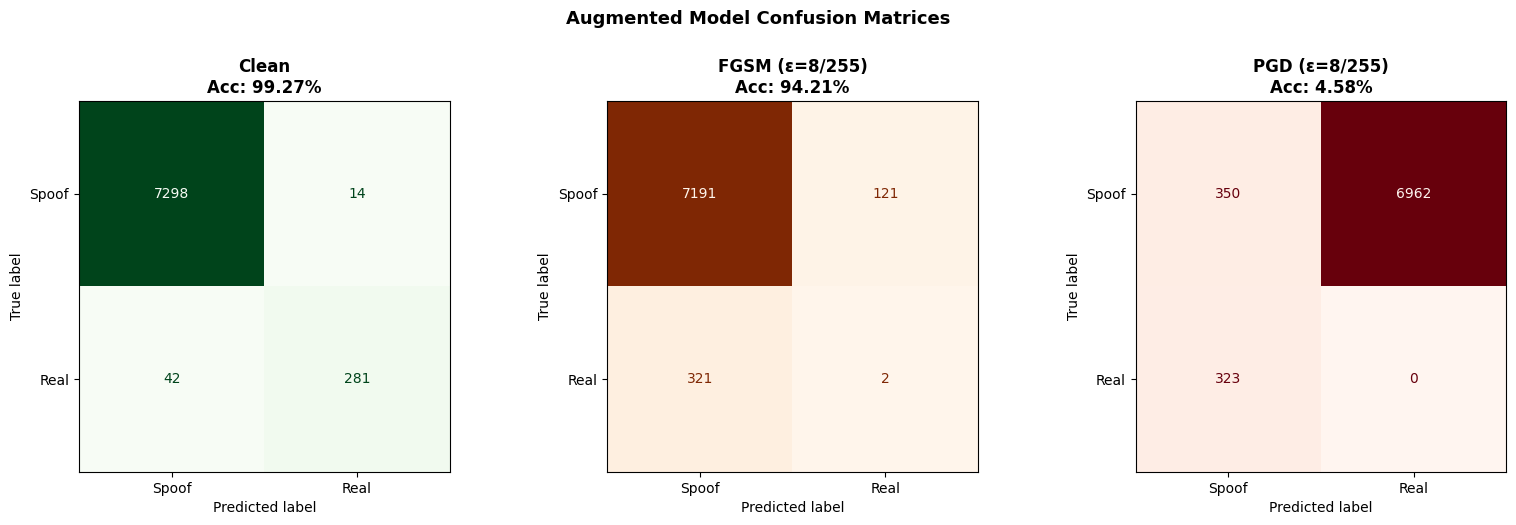

In [16]:
plot_bar(r_clean_aug, r_fgsm_aug, r_pgd_aug,
         "After Data Augmentation — Clean vs FGSM vs PGD",
         "/kaggle/working/aug_bar.png")

plot_cms(r_clean_aug, r_fgsm_aug, r_pgd_aug,
         "Augmented Model Confusion Matrices",
         "/kaggle/working/aug_cm.png")

**Analysis:** Data augmentation improves clean generalization. However, improvement against  
adversarial attacks is modest because augmentation does not explicitly expose the model to  
adversarial perturbations.

## 6. After Adversarial Training

### 6.1 Adversarial Training — FGSM (50% clean + 50% FGSM)

In [17]:
adv_fgsm_model = load_model(f"{MODELS_PATH}/best_1ft_adv_fgsm.pth",
                             build_best_model_finetune, CONFIG["device"])

adv_fgsm_cache = load_and_free("Adv. FGSM")

print("=== Adversarial Training FGSM ===")
r_clean_af, r_fgsm_af, r_pgd_af = full_eval(
    adv_fgsm_model, test_loader, CONFIG["device"],
    cache=adv_fgsm_cache
)
print_results(r_clean_af, r_fgsm_af, r_pgd_af, "Adversarial Training FGSM")

free_cache(adv_fgsm_cache)
del adv_fgsm_model; torch.cuda.empty_cache()


  Loading 'Adv. FGSM' ... 7635 images loaded | fgsm ~4.60 GB
=== Adversarial Training FGSM ===
  [1/3] Clean ...


  [2/3] FGSM  (from cache) ...


  [3/3] PGD   (from cache) ...



  Adversarial Training FGSM
Condition                          Acc    Prec     Rec      F1
------------------------------------------------------------
Clean                           96.90%  58.74%  89.47%  70.92%
FGSM (ε=8/255)                  68.62%  10.51%  85.45%  18.72%
PGD (ε=8/255)                    0.28%   0.00%   0.00%   0.00%
  Degradation FGSM: 96.90% → 68.62%  (Δ=-28.28%)
  Degradation PGD : 96.90% → 0.28%  (Δ=-96.62%)
   ✅ Cache freed.


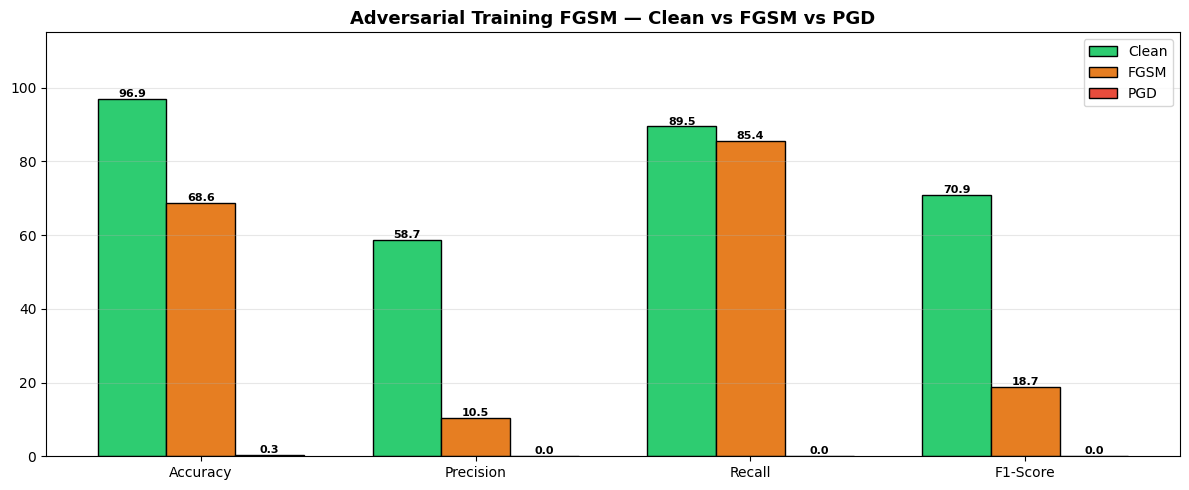

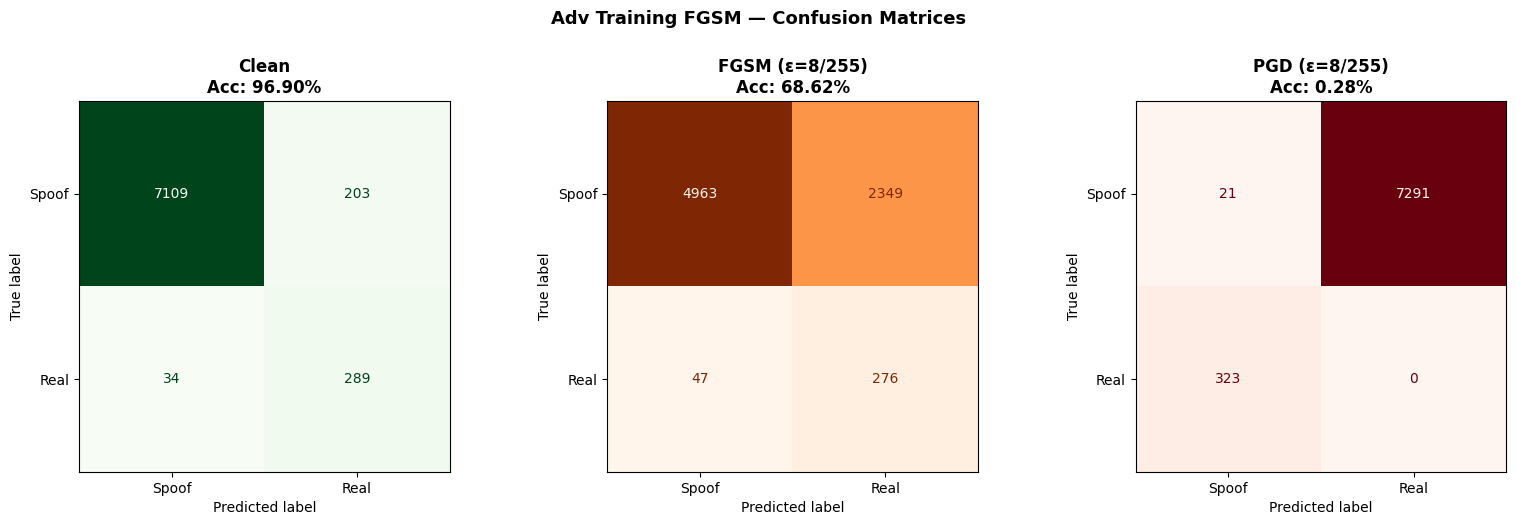

In [18]:
plot_bar(r_clean_af, r_fgsm_af, r_pgd_af,
         "Adversarial Training FGSM — Clean vs FGSM vs PGD",
         "/kaggle/working/adv_fgsm_bar.png")

plot_cms(r_clean_af, r_fgsm_af, r_pgd_af,
         "Adv Training FGSM — Confusion Matrices",
         "/kaggle/working/adv_fgsm_cm.png")

### 6.2 Adversarial Training — PGD (50% clean + 50% PGD)

In [19]:
adv_pgd_model = load_model(f"{MODELS_PATH}/best_1ft_adv_pgd.pth",
                            build_best_model_finetune, CONFIG["device"])

adv_pgd_cache = load_and_free("Adv. PGD")

print("=== Adversarial Training PGD ===")
r_clean_ap, r_fgsm_ap, r_pgd_ap = full_eval(
    adv_pgd_model, test_loader, CONFIG["device"],
    cache=adv_pgd_cache
)
print_results(r_clean_ap, r_fgsm_ap, r_pgd_ap, "Adversarial Training PGD")

free_cache(adv_pgd_cache)
del adv_pgd_model; torch.cuda.empty_cache()


  Loading 'Adv. PGD' ... 7635 images loaded | fgsm ~4.60 GB
=== Adversarial Training PGD ===
  [1/3] Clean ...


  [2/3] FGSM  (from cache) ...


  [3/3] PGD   (from cache) ...



  Adversarial Training PGD
Condition                          Acc    Prec     Rec      F1
------------------------------------------------------------
Clean                           90.28%  29.28%  91.64%  44.38%
FGSM (ε=8/255)                   4.23%   4.23% 100.00%   8.12%
PGD (ε=8/255)                    4.19%   4.18%  98.76%   8.02%
  Degradation FGSM: 90.28% → 4.23%  (Δ=-86.05%)
  Degradation PGD : 90.28% → 4.19%  (Δ=-86.09%)
   ✅ Cache freed.


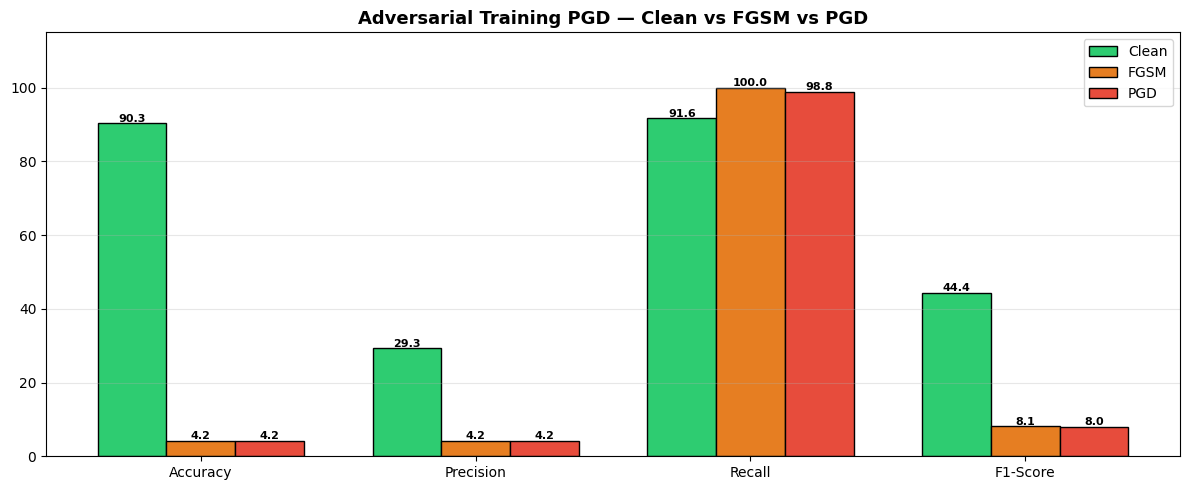

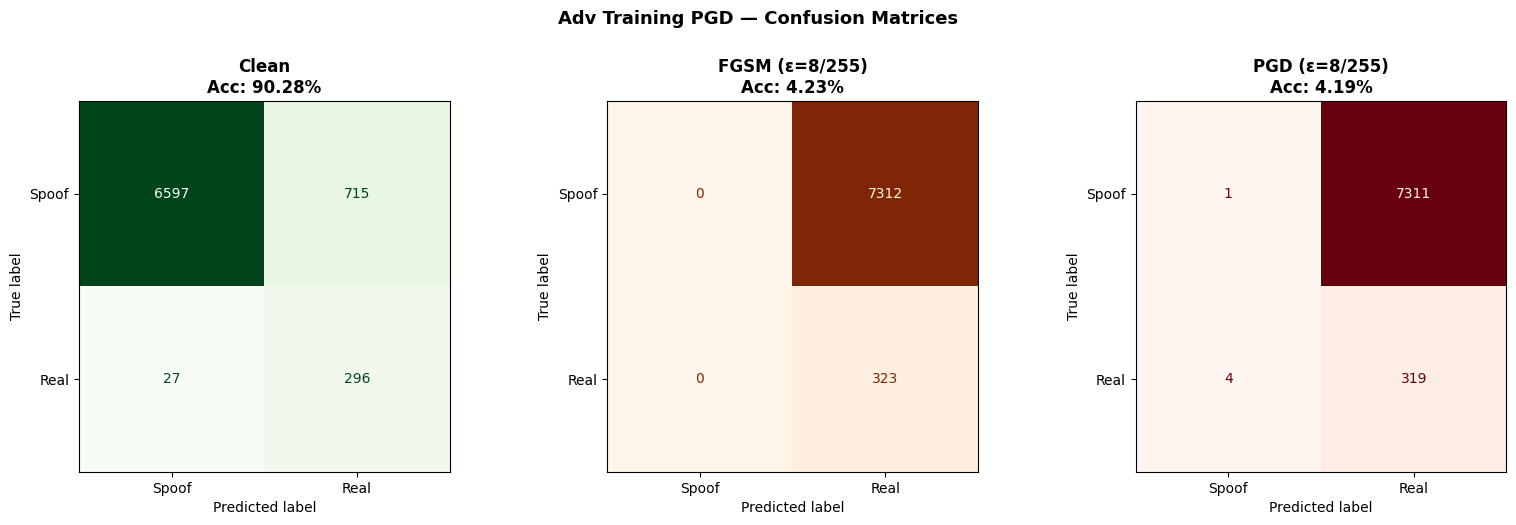

In [20]:
plot_bar(r_clean_ap, r_fgsm_ap, r_pgd_ap,
         "Adversarial Training PGD — Clean vs FGSM vs PGD",
         "/kaggle/working/adv_pgd_bar.png")

plot_cms(r_clean_ap, r_fgsm_ap, r_pgd_ap,
         "Adv Training PGD — Confusion Matrices",
         "/kaggle/working/adv_pgd_cm.png")

**Analysis:** PGD adversarial training substantially improves robustness against PGD attacks,  
often at the cost of a small drop in clean accuracy — the classic accuracy-robustness tradeoff.

## 7. Additional Experiments

### 7.1 Gaussian Filter Defense

In [21]:

best_strategy_name    = "1-Fine-tune"
best_strategy_path    = f"{MODELS_PATH}/best_1_fine_tune.pth"
best_strategy_builder = build_model_1_finetune

def gaussian_filter(images, kernel_size=7, sigma=1.0):
    ax     = torch.arange(kernel_size, dtype=torch.float32) - kernel_size // 2
    gauss  = torch.exp(-ax**2 / (2*sigma**2)); gauss /= gauss.sum()
    kernel = gauss.outer(gauss).unsqueeze(0).unsqueeze(0).repeat(3,1,1,1).to(images.device)
    return F.conv2d(images, kernel, padding=kernel_size//2, groups=3)


def eval_with_filter_from_cache(model, cached_imgs, cached_labels, device,
                                 filter_fn=None, filter_kw=None, desc=""):
    model.eval(); filter_kw = filter_kw or {}
    all_preds, all_labels = [], []
    n, bs = cached_imgs.shape[0], CONFIG["batch_size"]
    for start in tqdm(range(0, n, bs), desc=f"  {desc}", leave=False):
        imgs   = cached_imgs  [start:start+bs].to(device)
        labels = cached_labels[start:start+bs].to(device)
        if filter_fn:
            imgs = filter_fn(imgs, **filter_kw)
        with torch.no_grad():
            all_preds.extend(model(imgs).argmax(1).cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
    return {
        "f1"      : f1_score      (all_labels, all_preds, zero_division=0) * 100,
        "accuracy": accuracy_score(all_labels, all_preds) * 100
    }


# Gaussian filter evaluation uses the Baseline model + its own cache
baseline_model_gauss = load_model(best_strategy_path, best_strategy_builder, CONFIG["device"])
baseline_cache_gauss = load_and_free("Baseline")  # reload for Gaussian filter section

filter_cfgs = [
    ("No Filter",          None,           {}),
    ("Gaussian 3x3 s=0.5", gaussian_filter, {"kernel_size": 3, "sigma": 0.5}),
    ("Gaussian 5x5 s=1.0", gaussian_filter, {"kernel_size": 5, "sigma": 1.0}),
    ("Gaussian 7x7 s=1.5", gaussian_filter, {"kernel_size": 7, "sigma": 1.5}),
]

filt_fgsm, filt_pgd = {}, {}
for label, fn, kw in filter_cfgs:
    print(f"  {label} ...")
    filt_fgsm[label] = eval_with_filter_from_cache(
        baseline_model_gauss, baseline_cache_gauss.fgsm_imgs, baseline_cache_gauss.labels_tensor,
        CONFIG["device"], fn, kw, f"FGSM+{label}")
    filt_pgd[label]  = eval_with_filter_from_cache(
        baseline_model_gauss, baseline_cache_gauss.pgd_imgs,  baseline_cache_gauss.labels_tensor,
        CONFIG["device"], fn, kw, f"PGD+{label}")
    print(f"    FGSM  F1={filt_fgsm[label]['f1']:.2f}%  Acc={filt_fgsm[label]['accuracy']:.2f}%")
    print(f"    PGD   F1={filt_pgd [label]['f1']:.2f}%  Acc={filt_pgd [label]['accuracy']:.2f}%")

free_cache(baseline_cache_gauss)
del baseline_model_gauss; torch.cuda.empty_cache()


  Loading 'Baseline' ... 7635 images loaded | fgsm ~4.60 GB
  No Filter ...


    FGSM  F1=11.64%  Acc=67.98%
    PGD   F1=0.00%  Acc=0.16%
  Gaussian 3x3 s=0.5 ...


    FGSM  F1=9.92%  Acc=83.34%
    PGD   F1=0.06%  Acc=7.79%
  Gaussian 5x5 s=1.0 ...


    FGSM  F1=14.95%  Acc=94.04%
    PGD   F1=6.57%  Acc=91.80%
  Gaussian 7x7 s=1.5 ...


    FGSM  F1=4.12%  Acc=95.13%
    PGD   F1=2.02%  Acc=94.91%
   ✅ Cache freed.


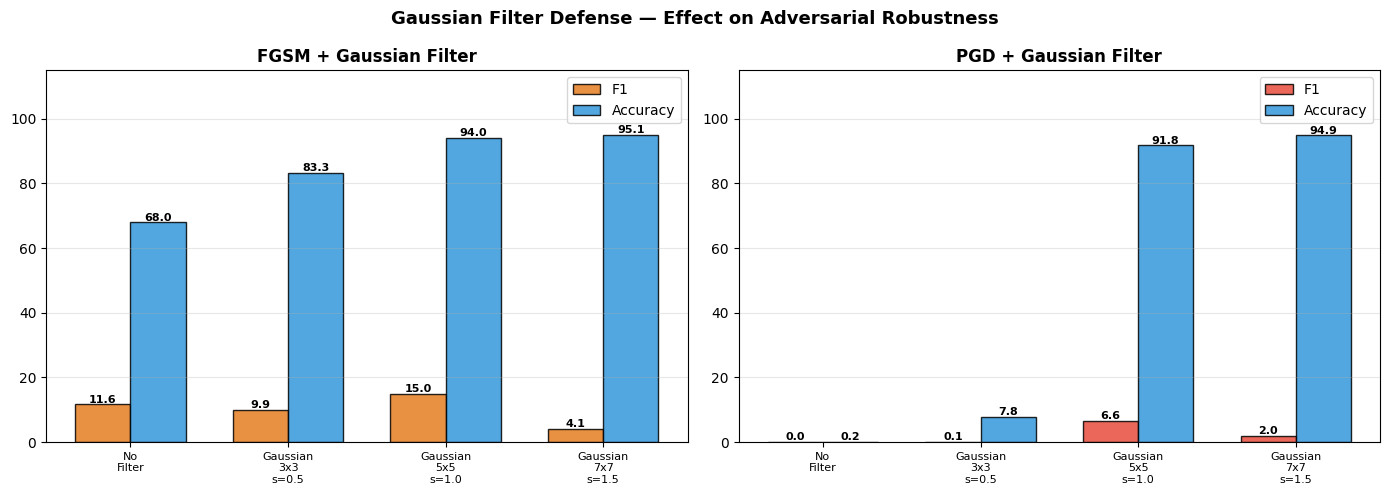

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Gaussian Filter Defense — Effect on Adversarial Robustness",
             fontsize=13, fontweight='bold')

for ax, (filt_dict, attack_name, color) in zip(
    axes,
    [(filt_fgsm, "FGSM", "#e67e22"), (filt_pgd, "PGD", "#e74c3c")]
):
    labels_g = list(filt_dict.keys())
    f1_vals  = [filt_dict[l]["f1"] for l in labels_g]
    acc_vals = [filt_dict[l]["accuracy"] for l in labels_g]
    x = np.arange(len(labels_g)); w = 0.35
    bars1 = ax.bar(x - w/2, f1_vals,  w, label="F1",      color=color,     edgecolor="black", alpha=0.85)
    bars2 = ax.bar(x + w/2, acc_vals, w, label="Accuracy", color="#3498db", edgecolor="black", alpha=0.85)
    ax.set_title(f"{attack_name} + Gaussian Filter", fontweight='bold')
    ax.set_xticks(x); ax.set_xticklabels([l.replace(' ','\n') for l in labels_g], fontsize=8)
    ax.set_ylim(0, 115); ax.legend(); ax.grid(axis='y', alpha=0.3)
    for b in list(bars1)+list(bars2):
        ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.5,
                f"{b.get_height():.1f}", ha='center', fontsize=8, fontweight='bold')

plt.tight_layout()
plt.savefig('/kaggle/working/gaussian_filter.png', dpi=150, bbox_inches='tight')
plt.show()


Visualizing best Gaussian filter configuration...
  Loading 'Baseline' ... 7635 images loaded | fgsm ~4.60 GB


   ✅ Cache freed.


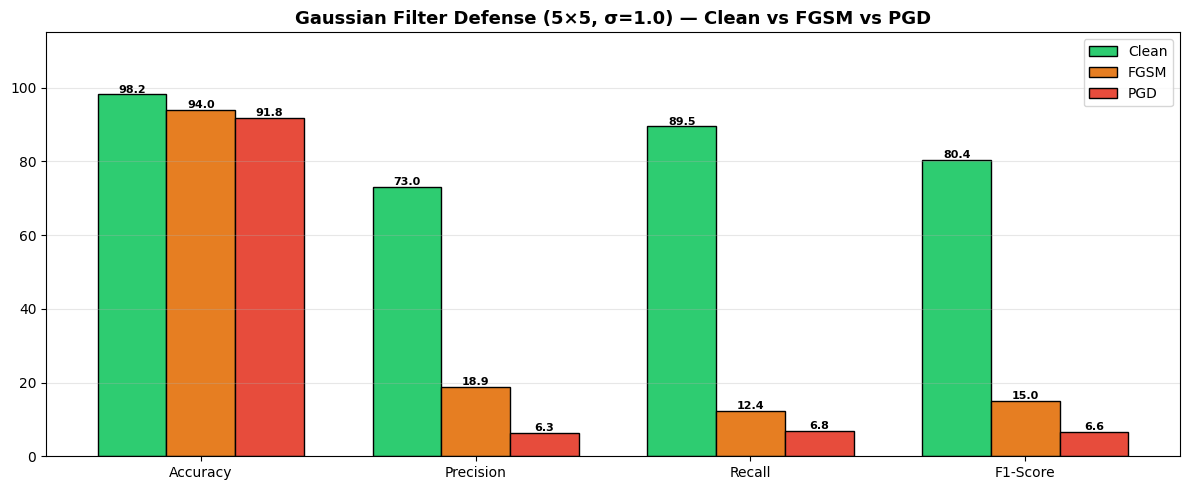

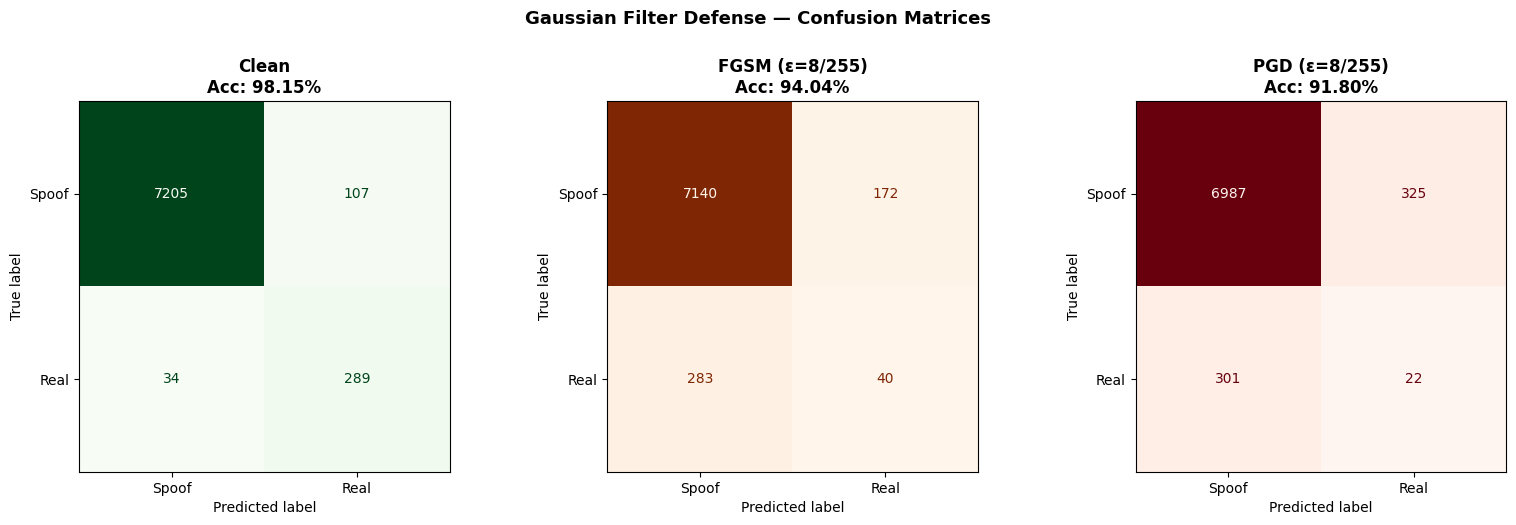

In [23]:
# Visualize best Gaussian filter configuration
print("\nVisualizing best Gaussian filter configuration...")

gauss_config = "Gaussian 5x5 s=1.0"

# Reload model and cache (freed at end of previous cell)
baseline_model_gauss2 = load_model(best_strategy_path, best_strategy_builder, CONFIG["device"])
baseline_cache_gauss2 = load_and_free("Baseline")

def eval_with_filter_full(model, cached_imgs, cached_labels, device, filter_fn=None, filter_kw=None, desc=""):
    """Same as eval_with_filter_from_cache but returns full result dict for plot_bar/plot_cms."""
    model.eval(); filter_kw = filter_kw or {}
    all_preds, all_labels = [], []
    n, bs = cached_imgs.shape[0], CONFIG["batch_size"]
    for start in tqdm(range(0, n, bs), desc=f"  {desc}", leave=False):
        imgs   = cached_imgs  [start:start+bs].to(device)
        labels = cached_labels[start:start+bs].to(device)
        if filter_fn:
            imgs = filter_fn(imgs, **filter_kw)
        with torch.no_grad():
            all_preds.extend(model(imgs).argmax(1).cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
    return {
        "accuracy" : accuracy_score (all_labels, all_preds) * 100,
        "precision": precision_score(all_labels, all_preds, zero_division=0) * 100,
        "recall"   : recall_score   (all_labels, all_preds, zero_division=0) * 100,
        "f1"       : f1_score       (all_labels, all_preds, zero_division=0) * 100,
        "labels"   : all_labels,
        "preds"    : all_preds,
    }

r_clean_gauss = eval_with_filter_full(
    baseline_model_gauss2, baseline_cache_gauss2.clean_imgs,
    baseline_cache_gauss2.labels_tensor, CONFIG["device"], desc="Clean")

r_fgsm_gauss = eval_with_filter_full(
    baseline_model_gauss2, baseline_cache_gauss2.fgsm_imgs,
    baseline_cache_gauss2.labels_tensor, CONFIG["device"],
    filter_fn=gaussian_filter, filter_kw={"kernel_size": 5, "sigma": 1.0}, desc="FGSM+Gauss5x5")

r_pgd_gauss = eval_with_filter_full(
    baseline_model_gauss2, baseline_cache_gauss2.pgd_imgs,
    baseline_cache_gauss2.labels_tensor, CONFIG["device"],
    filter_fn=gaussian_filter, filter_kw={"kernel_size": 5, "sigma": 1.0}, desc="PGD+Gauss5x5")

free_cache(baseline_cache_gauss2)
del baseline_model_gauss2
torch.cuda.empty_cache()

plot_bar(r_clean_gauss, r_fgsm_gauss, r_pgd_gauss,
         "Gaussian Filter Defense (5×5, σ=1.0) — Clean vs FGSM vs PGD",
         "/kaggle/working/gaussian_filter_bar.png")

plot_cms(r_clean_gauss, r_fgsm_gauss, r_pgd_gauss,
         "Gaussian Filter Defense — Confusion Matrices",
         "/kaggle/working/gaussian_filter_cm.png")

### 7.2 Mixed Attack Training (25% FGSM + 25% PGD)

  Loading 'Mixed Attack' ... 7635 images loaded | fgsm ~4.60 GB
=== Mixed Attack Training ===
  [1/3] Clean ...


  [2/3] FGSM  (from cache) ...


  [3/3] PGD   (from cache) ...



  Mixed Attack Training (25% FGSM + 25% PGD)
Condition                          Acc    Prec     Rec      F1
------------------------------------------------------------
Clean                           98.68%  87.25%  80.50%  83.74%
FGSM (ε=8/255)                  18.32%   4.83%  97.83%   9.20%
PGD (ε=8/255)                    0.17%   0.04%   0.93%   0.08%
  Degradation FGSM: 98.68% → 18.32%  (Δ=-80.35%)
  Degradation PGD : 98.68% → 0.17%  (Δ=-98.51%)


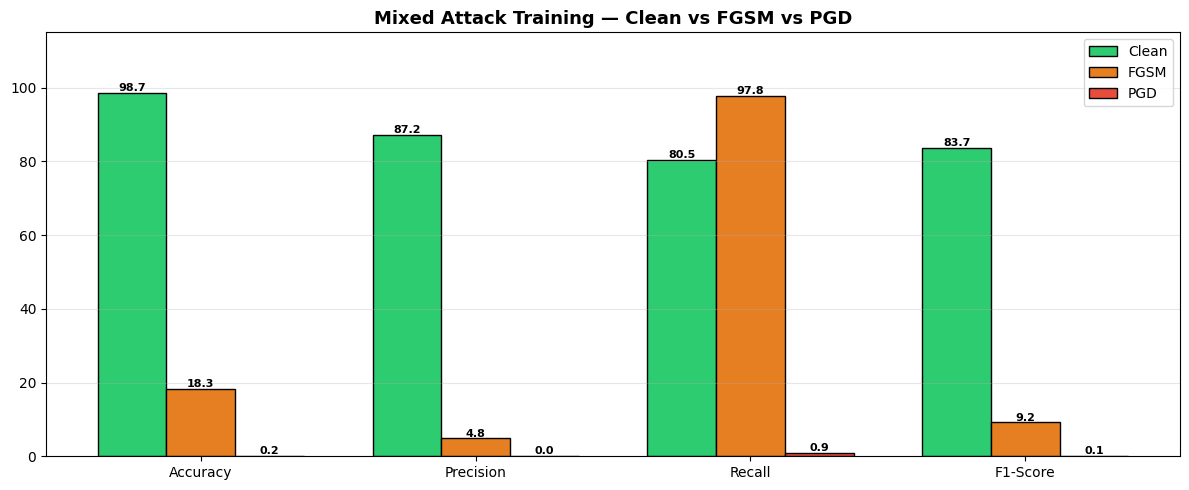

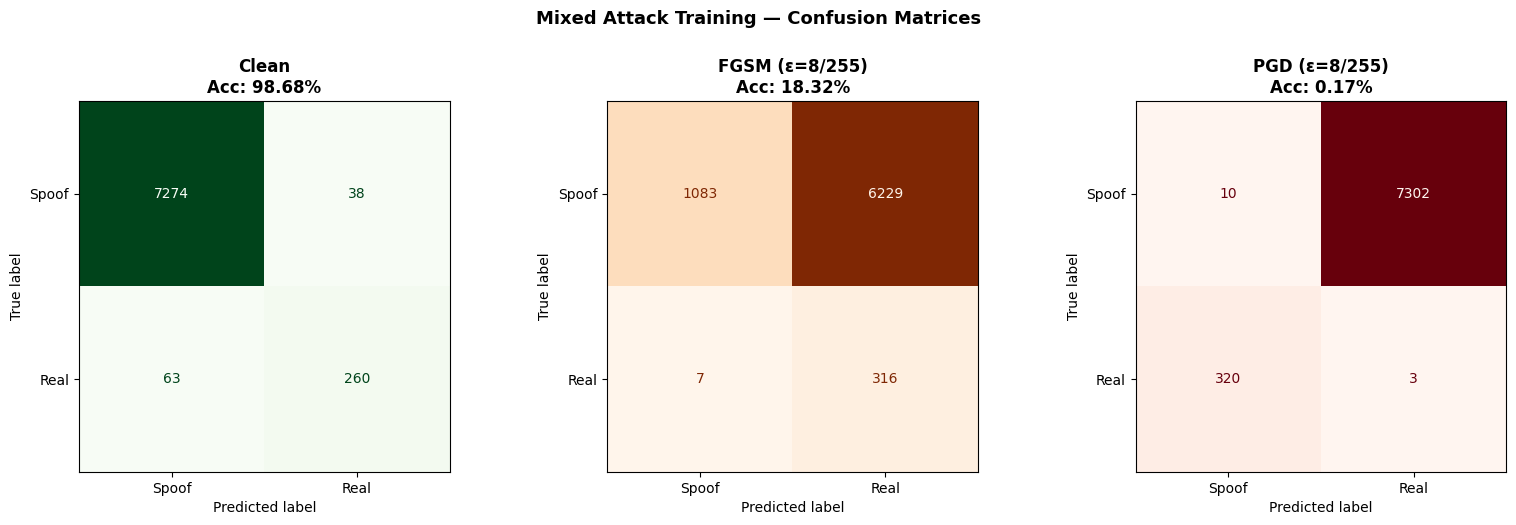

   ✅ Cache freed.


In [24]:
mixed_model = load_model(f"{MODELS_PATH}/best_adv_mixed.pth",
                          build_best_model_finetune, CONFIG["device"])

mixed_cache = load_and_free("Mixed Attack")

print("=== Mixed Attack Training ===")
r_clean_mx, r_fgsm_mx, r_pgd_mx = full_eval(
    mixed_model, test_loader, CONFIG["device"],
    cache=mixed_cache
)
print_results(r_clean_mx, r_fgsm_mx, r_pgd_mx, "Mixed Attack Training (25% FGSM + 25% PGD)")

plot_bar(r_clean_mx, r_fgsm_mx, r_pgd_mx,
         "Mixed Attack Training — Clean vs FGSM vs PGD",
         "/kaggle/working/mixed_bar.png")
plot_cms(r_clean_mx, r_fgsm_mx, r_pgd_mx,
         "Mixed Attack Training — Confusion Matrices",
         "/kaggle/working/mixed_cm.png")

free_cache(mixed_cache)
del mixed_model; torch.cuda.empty_cache()


### 7.3 Focal Loss vs Cross-Entropy

  Loading 'Focal Loss' ... 7635 images loaded | fgsm ~4.60 GB
=== Focal Loss vs Cross-Entropy ===
  [1/3] Clean ...


  [2/3] FGSM  (from cache) ...


  [3/3] PGD   (from cache) ...



  Focal Loss Model
Condition                          Acc    Prec     Rec      F1
------------------------------------------------------------
Clean                           97.92%  70.00%  88.85%  78.31%
FGSM (ε=8/255)                  58.15%   5.43%  54.18%   9.87%
PGD (ε=8/255)                    0.03%   0.00%   0.00%   0.00%
  Degradation FGSM: 97.92% → 58.15%  (Δ=-39.76%)
  Degradation PGD : 97.92% → 0.03%  (Δ=-97.89%)


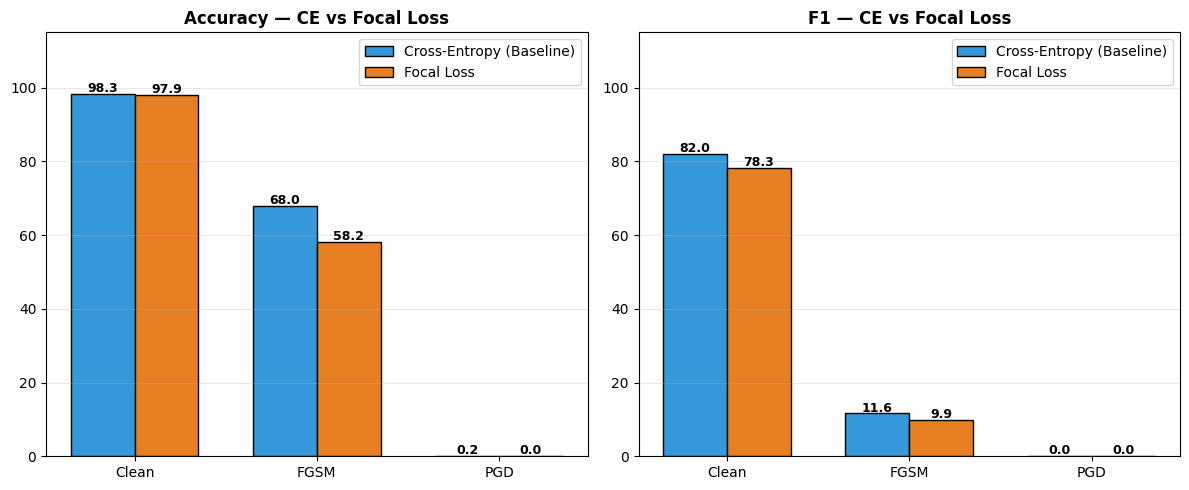

   ✅ Cache freed.


In [25]:
focal_model = load_model(f"{MODELS_PATH}/best_1ft_focal.pth",
                          build_best_model_finetune, CONFIG["device"])

focal_cache = load_and_free("Focal Loss")

print("=== Focal Loss vs Cross-Entropy ===")
r_clean_fl, r_fgsm_fl, r_pgd_fl = full_eval(
    focal_model, test_loader, CONFIG["device"],
    cache=focal_cache
)
print_results(r_clean_fl, r_fgsm_fl, r_pgd_fl, "Focal Loss Model")

# Side-by-side comparison vs Baseline
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
conditions = ["Clean", "FGSM", "PGD"]
for ax, metric in zip(axes, ["accuracy", "f1"]):
    x, w  = np.arange(3), 0.35
    ce_m  = [r_clean_base[metric], r_fgsm_base[metric], r_pgd_base[metric]]
    fl_m  = [r_clean_fl[metric],   r_fgsm_fl[metric],   r_pgd_fl[metric]]
    bars1 = ax.bar(x-w/2, ce_m, w, label="Cross-Entropy (Baseline)", color="#3498db", edgecolor="black")
    bars2 = ax.bar(x+w/2, fl_m, w, label="Focal Loss",               color="#e67e22", edgecolor="black")
    ax.set_title(f"{metric.capitalize()} — CE vs Focal Loss", fontweight='bold')
    ax.set_xticks(x); ax.set_xticklabels(conditions)
    ax.set_ylim(0, 115); ax.legend(); ax.grid(axis='y', alpha=0.3)
    for bar in list(bars1)+list(bars2):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
                f"{bar.get_height():.1f}", ha='center', fontsize=9, fontweight='bold')
plt.tight_layout()
plt.savefig("/kaggle/working/focal_vs_ce.png", dpi=150, bbox_inches='tight')
plt.show()

free_cache(focal_cache)
del focal_model; torch.cuda.empty_cache()


## 8. Worst-Case Robustness Testing

All models evaluated on 100% adversarial test images — the most challenging scenario.  
Each model is evaluated on **its own adversarial images** (per-model cache) for a fair comparison.

  Loading 'PGD Full Adv.' ... 7635 images loaded | fgsm ~4.60 GB
=== Full PGD Adversarial Training (Inner Maximization) ===
  [1/3] Clean ...


  [2/3] FGSM  (from cache) ...


  [3/3] PGD   (from cache) ...



  Full PGD Adversarial Training
Condition                          Acc    Prec     Rec      F1
------------------------------------------------------------
Clean                           94.29%  41.43%  84.52%  55.60%
FGSM (ε=8/255)                  94.62%  12.71%   4.64%   6.80%
PGD (ε=8/255)                   74.37%   0.00%   0.00%   0.00%
  Degradation FGSM: 94.29% → 94.62%  (Δ=0.33%)
  Degradation PGD : 94.29% → 74.37%  (Δ=-19.92%)
   ✅ Cache freed.


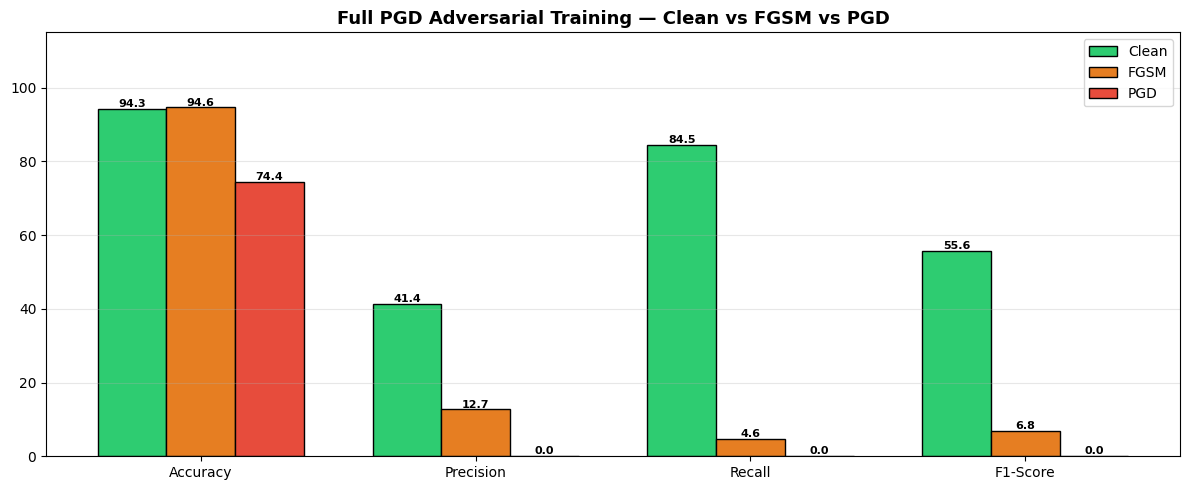

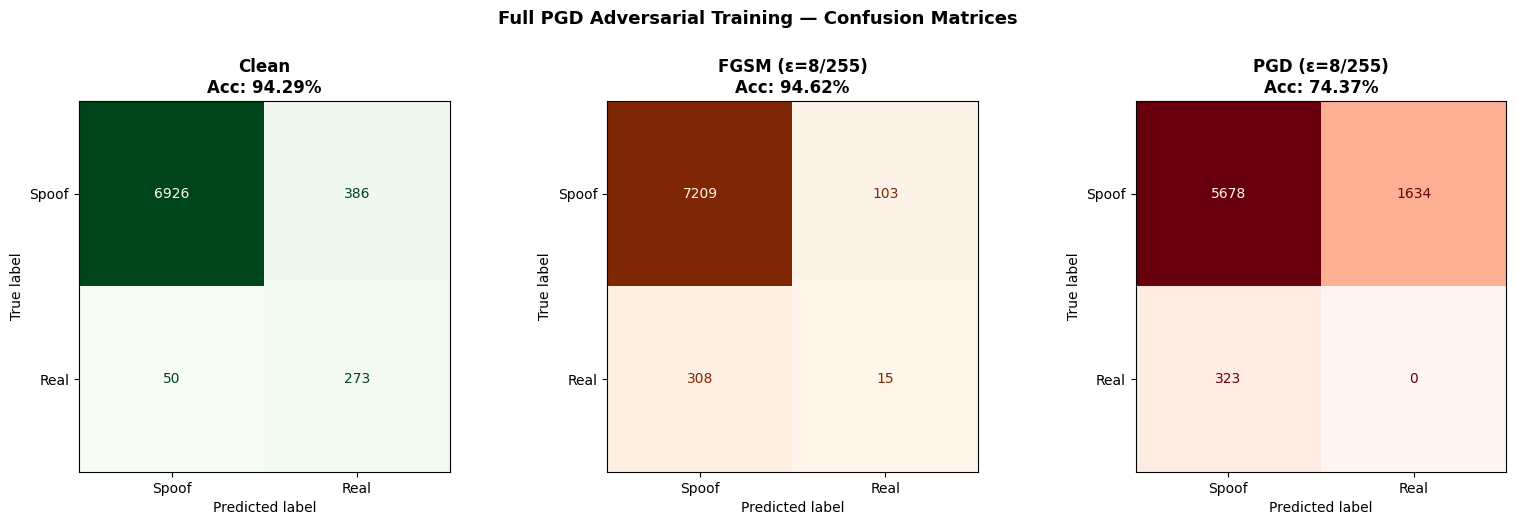

In [26]:
pgd_full_model = load_model(f"{MODELS_PATH}/best_pgd_adversarial_training.pth",
                             build_best_model_finetune, CONFIG["device"])

pgd_full_cache = load_and_free("PGD Full Adv.")

print("=== Full PGD Adversarial Training (Inner Maximization) ===")
r_clean_pgdf, r_fgsm_pgdf, r_pgd_pgdf = full_eval(
    pgd_full_model, test_loader, CONFIG["device"],
    cache=pgd_full_cache
)
print_results(r_clean_pgdf, r_fgsm_pgdf, r_pgd_pgdf, "Full PGD Adversarial Training")

free_cache(pgd_full_cache)
del pgd_full_model; torch.cuda.empty_cache()



# Visualize Full PGD Adversarial Training results
plot_bar(r_clean_pgdf, r_fgsm_pgdf, r_pgd_pgdf,
         "Full PGD Adversarial Training — Clean vs FGSM vs PGD",
         "/kaggle/working/full_pgd_adv_bar.png")

plot_cms(r_clean_pgdf, r_fgsm_pgdf, r_pgd_pgdf,
         "Full PGD Adversarial Training — Confusion Matrices",
         "/kaggle/working/full_pgd_adv_cm.png")


In [27]:
# Collect pre-computed results for all models
all_model_results = {
    "Baseline"      : (r_clean_base, r_fgsm_base, r_pgd_base),
    "Augmented"     : (r_clean_aug,  r_fgsm_aug,  r_pgd_aug),
    "Adv. FGSM"     : (r_clean_af,   r_fgsm_af,   r_pgd_af),
    "Adv. PGD"      : (r_clean_ap,   r_fgsm_ap,   r_pgd_ap),
    "Gaussian (5x5)": (r_clean_gauss, r_fgsm_gauss, r_pgd_gauss),
    "Mixed Attack"  : (r_clean_mx,   r_fgsm_mx,   r_pgd_mx),
    "Focal Loss"    : (r_clean_fl,   r_fgsm_fl,   r_pgd_fl),
    "PGD Full Adv." : (r_clean_pgdf, r_fgsm_pgdf, r_pgd_pgdf),
    
}

worst_results = {
    name: {"clean": rc, "fgsm": rf, "pgd": rp}
    for name, (rc, rf, rp) in all_model_results.items()
}

# Summary table
rows = []
for name, conds in worst_results.items():
    for cond_key, cond_label in [("clean","Clean"),("fgsm","FGSM"),("pgd","PGD")]:
        rows.append({"Model": name, "Condition": cond_label,
                     "Accuracy": round(conds[cond_key]["accuracy"], 2),
                     "F1":       round(conds[cond_key]["f1"], 2)})
df_worst = pd.DataFrame(rows)
print("\nWorst-Case Results (per-model adversarial images):")
print(df_worst.to_string(index=False))


Worst-Case Results (per-model adversarial images):
         Model Condition  Accuracy    F1
      Baseline     Clean     98.34 81.99
      Baseline      FGSM     67.98 11.64
      Baseline       PGD      0.16  0.00
     Augmented     Clean     99.27 90.94
     Augmented      FGSM     94.21  0.90
     Augmented       PGD      4.58  0.00
     Adv. FGSM     Clean     96.90 70.92
     Adv. FGSM      FGSM     68.62 18.72
     Adv. FGSM       PGD      0.28  0.00
      Adv. PGD     Clean     90.28 44.38
      Adv. PGD      FGSM      4.23  8.12
      Adv. PGD       PGD      4.19  8.02
Gaussian (5x5)     Clean     98.15 80.39
Gaussian (5x5)      FGSM     94.04 14.95
Gaussian (5x5)       PGD     91.80  6.57
  Mixed Attack     Clean     98.68 83.74
  Mixed Attack      FGSM     18.32  9.20
  Mixed Attack       PGD      0.17  0.08
    Focal Loss     Clean     97.92 78.31
    Focal Loss      FGSM     58.15  9.87
    Focal Loss       PGD      0.03  0.00
 PGD Full Adv.     Clean     94.29 55.60
 PGD 

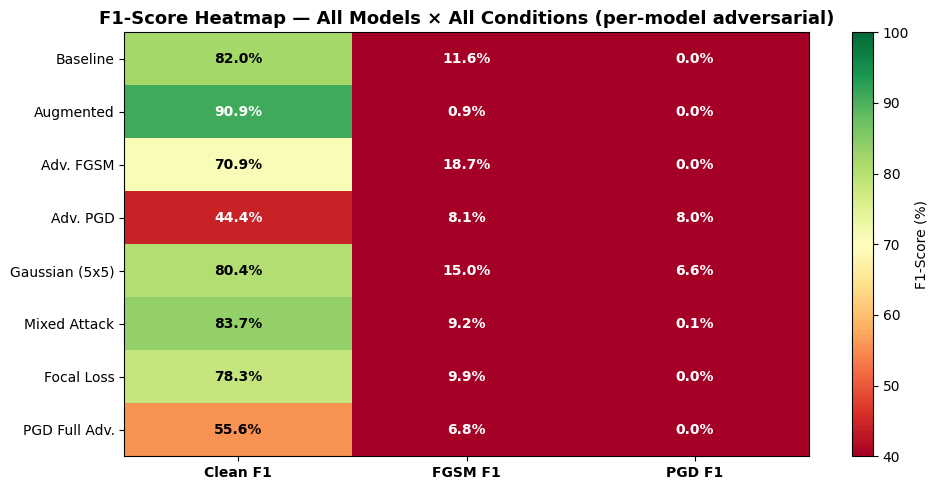

In [28]:
pivot = pd.DataFrame({
    name: {"Clean F1": conds["clean"]["f1"],
           "FGSM F1" : conds["fgsm"]["f1"],
           "PGD F1"  : conds["pgd"]["f1"]}
    for name, conds in worst_results.items()
}).T

fig, ax = plt.subplots(figsize=(10, 5))
im = ax.imshow(pivot.values, cmap='RdYlGn', vmin=40, vmax=100, aspect='auto')
ax.set_xticks(range(len(pivot.columns))); ax.set_xticklabels(pivot.columns, fontweight='bold')
ax.set_yticks(range(len(pivot.index)));   ax.set_yticklabels(pivot.index)
plt.colorbar(im, ax=ax, label='F1-Score (%)')
for i in range(len(pivot.index)):
    for j in range(len(pivot.columns)):
        ax.text(j, i, f"{pivot.values[i,j]:.1f}%", ha='center', va='center',
                fontsize=10, fontweight='bold',
                color='black' if 50 < pivot.values[i,j] < 90 else 'white')
ax.set_title("F1-Score Heatmap — All Models × All Conditions (per-model adversarial)", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig("/kaggle/working/heatmap_worst_case.png", dpi=150, bbox_inches='tight')
plt.show()

## 9. Final Comparison — All Models × All Conditions

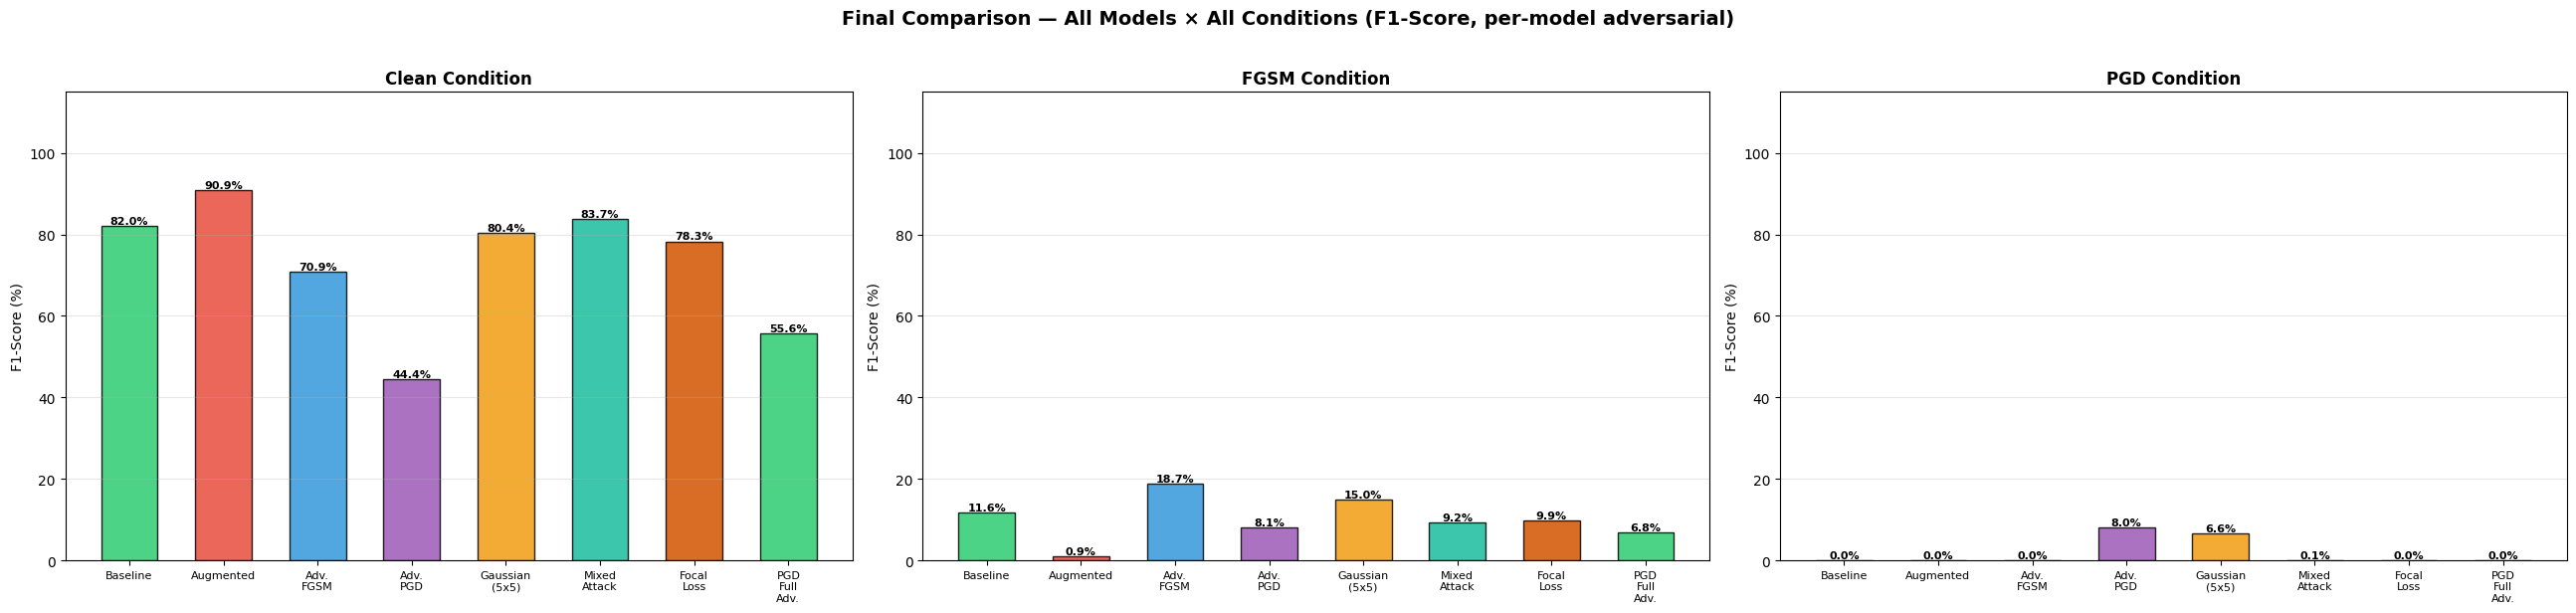


Final results saved to /kaggle/working/final_results.csv
         Model  Clean Acc  Clean F1  FGSM Acc  FGSM F1  PGD Acc  PGD F1
      Baseline      98.34     81.99     67.98    11.64     0.16    0.00
     Augmented      99.27     90.94     94.21     0.90     4.58    0.00
     Adv. FGSM      96.90     70.92     68.62    18.72     0.28    0.00
      Adv. PGD      90.28     44.38      4.23     8.12     4.19    8.02
Gaussian (5x5)      98.15     80.39     94.04    14.95    91.80    6.57
  Mixed Attack      98.68     83.74     18.32     9.20     0.17    0.08
    Focal Loss      97.92     78.31     58.15     9.87     0.03    0.00
 PGD Full Adv.      94.29     55.60     94.62     6.80    74.37    0.00

   Best strategy used: 1-Fine-tune  (F1=81.99%)
   Seed: 42 — fully reproducible
   Per-model adversarial images — fair white-box comparison


In [29]:
model_names = list(worst_results.keys())
colors      = ['#2ecc71','#e74c3c','#3498db','#9b59b6','#f39c12','#1abc9c','#d35400']
x, width    = np.arange(len(model_names)), 0.6

fig, axes = plt.subplots(1, 3, figsize=(26, 6))
fig.suptitle("Final Comparison — All Models × All Conditions (F1-Score, per-model adversarial)",
             fontsize=14, fontweight='bold', y=1.02)

for ax, cond_key, cond_lbl in zip(axes, ["clean","fgsm","pgd"], ["Clean","FGSM","PGD"]):
    vals = [worst_results[m][cond_key]["f1"] for m in model_names]
    bars = ax.bar(x, vals, width, color=colors[:len(model_names)], edgecolor='black', alpha=0.85)
    ax.set_title(f"{cond_lbl} Condition", fontweight='bold', fontsize=12)
    ax.set_xticks(x); ax.set_xticklabels([m.replace(' ','\n') for m in model_names], fontsize=8)
    ax.set_ylabel('F1-Score (%)'); ax.set_ylim(0, 115); ax.grid(axis='y', alpha=0.3)
    for b in bars:
        ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.5,
                f"{b.get_height():.1f}%", ha='center', fontsize=8, fontweight='bold')

plt.tight_layout()
plt.savefig('/kaggle/working/final_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Save final CSV ─────────────────────────────────────────────────────────────
df_final = pd.DataFrame([
    {"Model"    : name,
     "Clean Acc": round(conds["clean"]["accuracy"], 2),
     "Clean F1" : round(conds["clean"]["f1"], 2),
     "FGSM Acc" : round(conds["fgsm"]["accuracy"], 2),
     "FGSM F1"  : round(conds["fgsm"]["f1"], 2),
     "PGD Acc"  : round(conds["pgd"]["accuracy"], 2),
     "PGD F1"   : round(conds["pgd"]["f1"], 2)}
    for name, conds in worst_results.items()
])
df_final.to_csv("/kaggle/working/final_results.csv", index=False)
print("\nFinal results saved to /kaggle/working/final_results.csv")
print(df_final.to_string(index=False))

print(f"\n{'='*60}")
print(f"   Best strategy used: {best_strategy_name}  (F1={best_strategy_f1:.2f}%)")
print(f"   Seed: {SEED} — fully reproducible")
print(f"   Per-model adversarial images — fair white-box comparison")
print(f"{'='*60}")